# NSMC 감성 분류 — Bidirectional LSTM 단계별 실험

## 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **데이터셋** | NSMC (Naver Sentiment Movie Corpus) — 네이버 영화 리뷰 |
| **학습 데이터** | 150,000건 |
| **테스트 데이터** | 50,000건 |
| **목표** | Bidirectional LSTM으로 감성 분류 구현, Test Accuracy 85% 이상 달성 |
| **핵심 전략** | 한 번에 하나의 변수만 변경하며 단계별 성능 개선 추적 |

## 실험 아키텍처

```
Baseline (단방향 LSTM + morphs 전처리)
  ↓ 전처리 변경
Exp1: POS 필터링 (Noun/Verb/Adjective/Adverb/Exclamation)
  ↓ 모델 변경
Exp2: Bidirectional LSTM 도입
  ↓ 정규화 강화
Exp3: BiLSTM Regularized (Dropout 강화 + 유닛 축소)
  ↓ 시퀀스 길이 최적화
Exp4: MAX_LEN 최적화 (p95 기준)
  ↓ 학습 전략
Exp5: 학습률 스케줄링 (EarlyStopping + ReduceLROnPlateau)
  ↓ 어휘 확장
Exp6: Vocab 확장 (10,000 → 25,000) + MAX_LEN 150
  ↓ 배치 크기 조정
Exp7: Batch Size 축소 (128 → 64)
  ↓ 학습 데이터 확대
Exp8: Validation Split 축소 (0.2 → 0.1)
```

### 핵심 설계 원칙
- **변수 통제**: 각 실험에서 하나의 변수만 변경하여 개별 기법의 기여도를 정확히 측정
- **공정한 평가**: `validation_split`으로 train에서 검증 데이터를 분리하고, test는 학습 후 별도 평가
- **과적합 모니터링**: train/val accuracy gap을 매 실험마다 추적

---
## 0. 환경 설정 및 라이브러리 임포트

In [4]:
!pip install -q KoNLPy
!pip install -U -q sentencepiece

### 라이브러리 임포트 및 시드 고정
- **KoNLPy (Okt)**: 한국어 형태소 분석기
- **TensorFlow/Keras**: LSTM 모델 구축 및 학습
- **시드 고정 (SEED=42)**: 실험 재현성 보장

In [5]:
import numpy as np
import pandas as pd
import re
import time
import matplotlib.pyplot as plt

from konlpy.tag import Okt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

okt = Okt()
results = {}

---
## 1. 데이터 로드

NSMC 데이터셋을 Google Drive에서 로드
- `ratings_train.txt`: 학습 데이터 (150,000건)
- `ratings_test.txt`: 테스트 데이터 (50,000건)
- 각 행은 `id`, `document`(리뷰 텍스트), `label`(0: 부정, 1: 긍정)로 구성

In [6]:
from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = '/content/drive/MyDrive/ratings_train.txt'
TEST_PATH  = '/content/drive/MyDrive/ratings_test.txt'

train_data = pd.read_csv(TRAIN_PATH, delimiter='\t')
test_data  = pd.read_csv(TEST_PATH,  delimiter='\t')

print("전체 train shape:", train_data.shape)
print("전체 test  shape:", test_data.shape)
print("\n레이블 분포 (train):")
print(train_data['label'].value_counts())
train_data.head()

Mounted at /content/drive
전체 train shape: (150000, 3)
전체 test  shape: (50000, 3)

레이블 분포 (train):
label
0    75173
1    74827
Name: count, dtype: int64


,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...,1


### 결측치 제거
* NaN 값이 포함된 행을 제거함.
* 전체 데이터를 사용하여 학습 데이터 부족 문제를 방지함.(5만개의 데이터로 같은 실험을 한 결과, 실험이 성공적이지 못했음.)

In [7]:
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

print(f"전처리 후 → train: {train_data.shape}, test: {test_data.shape}")

전처리 후 → train: (149995, 3), test: (49997, 3)


---
## 2. 전처리 함수 정의

두 가지 전처리 방식을 비교:
1. **Baseline (morphs)**: `okt.morphs(stem=True)` — 모든 형태소를 분리, 1글자 토큰 제거
2. **POS 필터링**: `okt.pos(stem=True)` — 감성 분석에 유의미한 품사(명사/동사/형용사/부사/감탄사)만 추출

### 2-1) 베이스라인 전처리 (morphs)
- `re.sub`으로 한글과 공백만 남기고 특수문자 제거
- `okt.morphs(stem=True)`로 어간 추출 포함 형태소 분리
- 1글자 토큰 제거 (조사, 어미 등 의미 없는 단독 글자 필터링)

In [8]:
def preprocess_base(sentence):
    sentence = re.sub(r'\\n', ' ', str(sentence))
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)
    sentence = sentence.strip()
    if not sentence:
        return []
    tokens = okt.morphs(sentence, stem=True)
    tokens = [t for t in tokens if len(t) > 1]
    return tokens

### 2-2) POS 필터링 전처리
- `okt.pos(stem=True)`로 (단어, 품사) 쌍을 추출
- **Noun**(명사), **Verb**(동사), **Adjective**(형용사), **Adverb**(부사), **Exclamation**(감탄사)만 보존
- 부사를 포함한 이유: "너무", "정말", "안", "못" 등 감성 판단에 핵심적인 역할
- 조사, 어미, 접속사 등 기능어는 제거하여 노이즈 감소

In [9]:
KEEP_POS = {'Noun', 'Adjective', 'Verb', 'Adverb', 'Exclamation'}

def preprocess_pos(sentence):
    sentence = re.sub(r'\\n', ' ', str(sentence))
    sentence = re.sub('[^가-힣ㄱ-ㅎㅏ-ㅣ ]', '', sentence)
    sentence = sentence.strip()
    if not sentence:
        return []
    pos_tags = okt.pos(sentence, stem=True)
    tokens   = [word for word, pos in pos_tags
                if pos in KEEP_POS and len(word) > 1]
    return tokens


### 2-3) 전처리 실행 함수
- 전처리 함수를 인자로 받아 train/test 데이터에 일괄 적용
- 빈 토큰 리스트는 제외 (전처리 후 토큰이 없는 문장 방어)
- 진행 상황을 10,000건마다 출력하여 모니터링

In [10]:
def run_preprocessing(preprocess_fn, label=""):
    print(f"\n[전처리 시작] {label}")
    train_sents, train_labels = [], []
    test_sents,  test_labels  = [], []
    start = time.time()

    for i, (sent, lbl) in enumerate(
            zip(train_data['document'], train_data['label'])):
        if i % 10000 == 0:
            print(f"  train {i}/{len(train_data)}")
        tokens = preprocess_fn(sent)
        if tokens:
            train_sents.append(tokens)
            train_labels.append(lbl)

    for i, (sent, lbl) in enumerate(
            zip(test_data['document'], test_data['label'])):
        if i % 10000 == 0:
            print(f"  test  {i}/{len(test_data)}")
        tokens = preprocess_fn(sent)
        if tokens:
            test_sents.append(tokens)
            test_labels.append(lbl)

    print(f"  완료: {time.time()-start:.1f}s | "
          f"train {len(train_sents)}개, test {len(test_sents)}개")

    return (train_sents, np.array(train_labels),
            test_sents,  np.array(test_labels))


---
## 3. 모델 정의

3가지 모델 아키텍처를 단계적으로 사용:

| 모델 | 구조 | 용도 |
|------|------|------|
| `build_baseline` | Embedding(64) → LSTM(64) → Dense(32) → Dense(1) | Baseline, Exp1 |
| `build_bilstm` | Embedding(128) → BiLSTM(128) → Dense(64) → Dense(1) | Exp2 (BiLSTM 효과 측정) |
| `build_bilstm_regularized` | Embedding(64) → Dropout(0.3) → BiLSTM(64) → Dense(32) → Dropout(0.5) → Dense(1) | Exp3~Exp8 (과적합 억제) |

### 3-1) Baseline 모델
- 단방향 LSTM(64) 사용
- Dropout 없음 → 과적합에 취약하지만 기준 성능 측정용

In [11]:
def build_baseline(vocab_size, max_len):
    model = Sequential([
        Embedding(vocab_size + 1, 64, input_length=max_len),  # [수정] input_length 추가
        LSTM(64),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### 3-2) Bidirectional LSTM 모델
- **Bidirectional LSTM(128)**: 순방향 + 역방향을 동시에 학습하여 앞뒤 문맥 반영
- **Dropout(0.3)**: Dense 레이어 후 30% 뉴런 비활성화
- Baseline 대비 모델 구조 변경 효과를 측정하기 위한 모델

In [12]:
def build_bilstm(vocab_size, max_len):
    model = Sequential([
        Embedding(vocab_size + 1, 128, input_length=max_len),
        Bidirectional(LSTM(128, dropout=0.2, recurrent_dropout=0.2)),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

### 3-3) BiLSTM Regularized 모델 (과적합 억제)
- **유닛 축소**: Embedding 128→64, LSTM 128→64, Dense 64→32
  - 모델 용량을 줄여 개별 표현을 외우는 대신 일반적인 패턴만 학습하도록 유도
- **Dropout 강화**: Embedding 뒤 0.3, Dense 뒤 0.5
  - 뉴런의 50%를 랜덤 비활성화하여 특정 뉴런 조합에 의존하는 것을 방지
- **recurrent_dropout=0.0**: cuDNN 가속 활성화를 위해 제거 (학습 속도 3~5배 향상)
- 목표: train accuracy가 다소 낮아지더라도 val과의 gap을 줄여 실제 성능 향상

In [13]:
def build_bilstm_regularized(vocab_size, max_len):
    model = Sequential([
        Embedding(vocab_size + 1, 64, input_length=max_len),
        Dropout(0.3),
        Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.0)),
        Dense(32, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        loss='binary_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

---
## 4. 실험 실행 함수 (`run_experiment`)

모든 실험에서 공통으로 사용하는 파이프라인:
1. **Tokenizer 생성**: train 데이터로만 어휘 사전 구축 (test 정보 유출 방지)
2. **시퀀스 변환**: `texts_to_sequences` → `pad_sequences` (post padding/truncating)
3. **검증**: 첫 샘플 역변환으로 전처리가 올바르게 되었는지 확인
4. **학습**: `validation_split`으로 train의 일부를 검증용으로 분리
5. **평가**: test 데이터는 `model.evaluate()`로 학습 후 별도 평가
6. **결과 기록**: Test Accuracy, 과적합 gap 등 핵심 지표 출력

> **주요 설계 결정**: `validation_data=(test_pad, test_labels)` 대신 `validation_split` 사용
> - test를 validation으로 직접 사용하면 모델이 test 정보를 간접적으로 학습에 활용
> - `validation_split`으로 분리하면 test는 완전히 독립된 평가 데이터로 유지

In [14]:
def run_experiment(name, train_sents, test_sents,
                   train_labels, test_labels,
                   vocab_size, max_len, build_fn,
                   epochs=20, batch_size=128, callbacks=None,
                   val_split=0.2):

    print(f"\n{'='*50}")
    print(f"  실험: {name}")
    print(f"  vocab_size={vocab_size}, max_len={max_len}")
    print(f"{'='*50}")

    # Tokenizer 생성 (train으로만 사전 구축)
    tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
    tokenizer.fit_on_texts(train_sents)

    train_seq = tokenizer.texts_to_sequences(train_sents)
    test_seq  = tokenizer.texts_to_sequences(test_sents)

    train_pad = pad_sequences(train_seq, maxlen=max_len,
                               padding='post', truncating='post')
    test_pad  = pad_sequences(test_seq,  maxlen=max_len,
                               padding='post', truncating='post')

    print(f"  train_pad: {train_pad.shape}, test_pad: {test_pad.shape}")

    # 토크나이저 검증 (첫 샘플 역변환)
    reverse_word_index = {v: k for k, v in tokenizer.word_index.items()}
    decoded = ' '.join([reverse_word_index.get(i, '<pad>')
                        for i in train_pad[0] if i != 0])
    print(f"  [검증] 첫 샘플 역변환: {decoded[:80]}")

    # 모델 생성 및 학습
    model = build_fn(vocab_size, max_len)
    model.summary()

    # ✅ [수정 3] validation_split 사용
    # ❌ 기존: validation_data=(test_pad, test_labels)
    history = model.fit(
        train_pad, train_labels,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=val_split,       # [수정] train의 20%를 validation으로 분리
        callbacks=callbacks,
        verbose=1
    )

    # ✅ [수정 3] test 데이터는 별도로 평가
    test_loss, test_acc = model.evaluate(test_pad, test_labels, verbose=0)
    print(f"\n  [{name}] Test Accuracy: {test_acc*100:.2f}%")
    print(f"  [{name}] Test Loss: {test_loss:.4f}")

    best_val_acc = max(history.history['val_accuracy'])
    min_val_acc  = min(history.history['val_accuracy'])
    avg_val_acc  = np.mean(history.history['val_accuracy'])
    best_epoch   = np.argmax(history.history['val_accuracy']) + 1

    train_acc = history.history['accuracy']
    val_acc   = history.history['val_accuracy']
    gap = max(train_acc) - max(val_acc)

    val_loss     = history.history['val_loss']
    min_val_loss = min(val_loss)
    best_loss_epoch = np.argmin(val_loss) + 1

    last_train_acc = train_acc[-1]
    last_val_acc   = val_acc[-1]
    drop_from_best = best_val_acc - last_val_acc

    # results에 test_acc 저장 (기존: val_accuracy의 max)
    results[name] = round(test_acc * 100, 2)

    print(f"\n  [{name}] 최고 val_accuracy: {best_val_acc*100:.2f}%")
    print(f"  [{name}] 최저 val_accuracy: {min_val_acc*100:.2f}%")
    print(f"  [{name}] 평균 val_accuracy: {avg_val_acc*100:.2f}%")
    print(f"  [{name}] 최고 epoch: {best_epoch}")
    print(f"  [{name}] 과적합 gap: {gap*100:.2f}%")
    print(f"  [{name}] 최소 val_loss: {min_val_loss:.4f}")
    print(f"  [{name}] 최소 val_loss epoch: {best_loss_epoch}")
    print(f"  [{name}] 마지막 train_accuracy: {last_train_acc*100:.2f}%")
    print(f"  [{name}] 마지막 val_accuracy: {last_val_acc*100:.2f}%")
    print(f"  [{name}] 최고 대비 마지막 val_accuracy 하락폭: {drop_from_best*100:.2f}%")
    print(f"  [{name}] ★ Test Accuracy (최종 성능): {test_acc*100:.2f}%")

    return history, model, tokenizer

---
## 5. 실험 실행

각 실험에서 한 가지 변수만 변경하여 개별 기법의 효과를 측정함.

### 5-1) Baseline
- **전처리**: morphs (모든 형태소 분리)
- **모델**: 단방향 LSTM(64)
- **vocab_size**: 10,000 / **max_len**: 15
- 모든 실험의 기준점이 되는 성능 측정

In [15]:
(train_sents_base, train_labels_base,
 test_sents_base,  test_labels_base) = run_preprocessing(
    preprocess_base, "Baseline (morphs)")

hist_base, model_base, tok_base = run_experiment(
    name         = 'Baseline',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,
    max_len      = 15,
    build_fn     = build_baseline,
    epochs       = 20
)


[전처리 시작] Baseline (morphs)
  train 0/149995
  train 10000/149995
  train 20000/149995
  train 30000/149995
  train 40000/149995
  train 50000/149995
  train 60000/149995
  train 70000/149995
  train 80000/149995
  train 90000/149995
  train 100000/149995
  train 110000/149995
  train 120000/149995
  train 130000/149995
  train 140000/149995
  test  0/49997
  test  10000/49997
  test  20000/49997
  test  30000/49997
  test  40000/49997
  완료: 356.0s | train 147737개, test 49240개

  실험: Baseline
  vocab_size=10000, max_len=15
  train_pad: (147737, 15), test_pad: (49240, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7954 - loss: 0.4285 - val_accuracy: 0.8237 - val_loss: 0.3892
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8389 - loss: 0.3552 - val_accuracy: 0.8237 - val_loss: 0.3874
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8596 - loss: 0.3134 - val_accuracy: 0.8294 - val_loss: 0.3943
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.8829 - loss: 0.2680 - val_accuracy: 0.8222 - val_loss: 0.4452
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9017 - loss: 0.2317 - val_accuracy: 0.8144 - val_loss: 0.4941
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9128 - loss: 0.2079 - val_accuracy: 0.8075 - val_loss: 0.5626
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9196 - loss: 0.1939 - val_accuracy: 0.8079 - val_loss: 0.5945
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9258 - loss: 0.1803 - val_accuracy: 

### 5-2) Exp1: POS 필터링
- **변경**: 전처리만 morphs → POS 필터링으로 교체
- **모델**: Baseline과 동일 (변수 통제)
- **기대 효과**: 기능어 제거로 노이즈 감소
- **검증 포인트**: 전처리 방식 변경이 성능에 미치는 영향

In [16]:
(train_sents_pos, train_labels_pos,
 test_sents_pos,  test_labels_pos) = run_preprocessing(
    preprocess_pos, "Exp1 (POS filtering with Adverb)")

hist_exp1, model_exp1, tok_exp1 = run_experiment(
    name         = 'Exp1_POS',
    train_sents  = train_sents_pos,
    test_sents   = test_sents_pos,
    train_labels = train_labels_pos,
    test_labels  = test_labels_pos,
    vocab_size   = 10000,
    max_len      = 15,
    build_fn     = build_baseline,   # 모델 동일
    epochs       = 20
)


[전처리 시작] Exp1 (POS filtering with Adverb)
  train 0/149995
  train 10000/149995
  train 20000/149995
  train 30000/149995
  train 40000/149995
  train 50000/149995
  train 60000/149995
  train 70000/149995
  train 80000/149995
  train 90000/149995
  train 100000/149995
  train 110000/149995
  train 120000/149995
  train 130000/149995
  train 140000/149995
  test  0/49997
  test  10000/49997
  test  20000/49997
  test  30000/49997
  test  40000/49997
  완료: 987.7s | train 147283개, test 49070개

  실험: Exp1_POS
  vocab_size=10000, max_len=15
  train_pad: (147283, 15), test_pad: (49070, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.7945 - loss: 0.4310 - val_accuracy: 0.8152 - val_loss: 0.4072
Epoch 2/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8361 - loss: 0.3623 - val_accuracy: 0.8242 - val_loss: 0.3880
Epoch 3/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8537 - loss: 0.3242 - val_accuracy: 0.8235 - val_loss: 0.4176
Epoch 4/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8762 - loss: 0.2799 - val_accuracy: 0.8197 - val_loss: 0.4612
Epoch 5/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8974 - loss: 0.2411 - val_accuracy: 0.8059 - val_loss: 0.4921
Epoch 6/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9080 - loss: 0.2203 - val_accuracy: 0.8066 - val_loss: 0.5062
Epoch 7/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9136 - loss: 0.2050 - val_accuracy: 0.8104 - val_loss: 0.5166
Epoch 8/20
921/921 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9195 - loss: 0.1915 - val_accuracy: 0

### 5-3) Exp2: Bidirectional LSTM 도입
- **변경**: 모델만 `build_baseline` → `build_bilstm`으로 교체
- **전처리**: morphs (Exp1에서 POS 필터링 효과가 미미하여 morphs로 복귀)
- **기대 효과**: 양방향 문맥 학습으로 성능 향상
- **검증 포인트**: BiLSTM 구조 자체의 기여도 측정

In [17]:
hist_exp2, model_exp2, tok_exp2 = run_experiment(
    name         = 'Exp2_BiLSTM',
    train_sents  = train_sents_base,   # morphs 전처리 사용
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,
    max_len      = 15,
    build_fn     = build_bilstm,
    epochs       = 20
)


  실험: Exp2_BiLSTM
  vocab_size=10000, max_len=15
  train_pad: (147737, 15), test_pad: (49240, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 112s 109ms/step - accuracy: 0.8003 - loss: 0.4244 - val_accuracy: 0.8269 - val_loss: 0.3835
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 99s 107ms/step - accuracy: 0.8457 - loss: 0.3464 - val_accuracy: 0.8301 - val_loss: 0.3808
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 100s 108ms/step - accuracy: 0.8663 - loss: 0.3055 - val_accuracy: 0.8267 - val_loss: 0.4110
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 142s 108ms/step - accuracy: 0.8859 - loss: 0.2662 - val_accuracy: 0.8172 - val_loss: 0.4481
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 105s 113ms/step - accuracy: 0.9022 - loss: 0.2327 - val_accuracy: 0.8175 - val_loss: 0.5086
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 99s 108ms/step - accuracy: 0.9138 - loss: 0.2063 - val_accuracy: 0.8144 - val_loss: 0.5934
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 99s 107ms/step - accuracy: 0.9212 - loss: 0.1883 - val_accuracy: 0.8139 - val_loss: 0.6318
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 100s 108ms/step - accuracy: 0.9286 - lo

### 5-4) Exp3: BiLSTM Regularized (과적합 억제)
- **변경**: 모델만 `build_bilstm` → `build_bilstm_regularized`로 교체
- **전처리/하이퍼파라미터**: Exp2와 동일
- **기대 효과**: Dropout 강화 + 유닛 축소로 과적합 gap 감소
- **검증 포인트**: 정규화 전략이 일반화 성능에 미치는 영향

In [18]:
hist_exp3, model_exp3, tok_exp3 = run_experiment(
    name         = 'Exp3_BiLSTM_Reg',
    train_sents  = train_sents_base,    # morphs 전처리 (Exp2와 동일)
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,               # Exp2와 동일
    max_len      = 15,                  # Exp2와 동일
    build_fn     = build_bilstm_regularized,  # 여기만 변경
    epochs       = 20
)


  실험: Exp3_BiLSTM_Reg
  vocab_size=10000, max_len=15
  train_pad: (147737, 15), test_pad: (49240, 15)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.7886 - loss: 0.4487 - val_accuracy: 0.8194 - val_loss: 0.4022
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8370 - loss: 0.3733 - val_accuracy: 0.8275 - val_loss: 0.3830
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.8475 - loss: 0.3477 - val_accuracy: 0.8298 - val_loss: 0.3842
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8578 - loss: 0.3272 - val_accuracy: 0.8315 - val_loss: 0.3923
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8656 - loss: 0.3085 - val_accuracy: 0.8317 - val_loss: 0.4090
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8742 - loss: 0.2920 - val_accuracy: 0.8276 - val_loss: 0.4270
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8814 - loss: 0.2773 - val_accuracy: 0.8238 - val_loss: 0.4572
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8871 - loss: 0.2645 - val

### 5-5) MAX_LEN 분석
토큰 길이 분포를 분석하여 최적의 시퀀스 길이를 결정함.
- 95th percentile 기준으로 MAX_LEN을 설정
- 너무 짧으면 정보 손실, 너무 길면 불필요한 패딩으로 노이즈 증가


[MAX_LEN 분석]
  평균: 8.1 | 중간값: 6.0
  80th percentile: 11 | 95th percentile: 24


/tmp/ipykernel_7968/1251936467.py:16: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/1251936467.py:16: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/1251936467.py:16: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/1251936467.py:16: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/1251936467.py:16: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/1251936467.py:16: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from fo

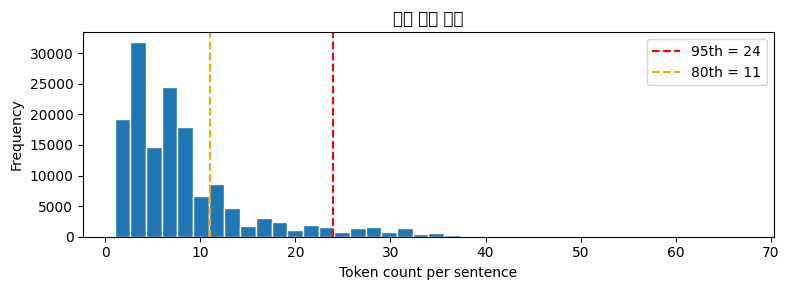

  → 선택된 MAX_LEN: 24


In [19]:
lengths = [len(s) for s in train_sents_pos]
p80 = int(np.percentile(lengths, 80))
p95 = int(np.percentile(lengths, 95))
print(f"\n[MAX_LEN 분석]")
print(f"  평균: {np.mean(lengths):.1f} | 중간값: {np.median(lengths):.1f}")
print(f"  80th percentile: {p80} | 95th percentile: {p95}")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, edgecolor='white')
plt.axvline(p95, color='red',    linestyle='--', label=f'95th = {p95}')
plt.axvline(p80, color='orange', linestyle='--', label=f'80th = {p80}')
plt.xlabel('Token count per sentence')
plt.ylabel('Frequency')
plt.title('문장 길이 분포')
plt.legend()
plt.tight_layout()
plt.show()

# 데이터 분포에 맞춰 MAX_LEN 선택 (p95 기준)
OPT_MAX_LEN = p95
print(f"  → 선택된 MAX_LEN: {OPT_MAX_LEN}")

### 5-6) Exp4: MAX_LEN 최적화
- **변경**: max_len만 15 → p95 기준값으로 변경
- **vocab_size**: 10,000 유지 (변수 통제)
- **기대 효과**: 데이터 분포에 맞는 시퀀스 길이로 정보 손실 최소화

In [20]:
hist_exp4, model_exp4, tok_exp4 = run_experiment(
    name         = 'Exp4_MaxLen',
    train_sents  = train_sents_base,   # morphs 전처리 사용
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,           # [수정] 기존 20000 → 10000 유지 (변수 통제)
    max_len      = OPT_MAX_LEN,     # 이것만 변경
    build_fn     = build_bilstm_regularized,
    epochs       = 20
)


  실험: Exp4_MaxLen
  vocab_size=10000, max_len=24
  train_pad: (147737, 24), test_pad: (49240, 24)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.7952 - loss: 0.4373 - val_accuracy: 0.8281 - val_loss: 0.3823
Epoch 2/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8411 - loss: 0.3644 - val_accuracy: 0.8319 - val_loss: 0.3722
Epoch 3/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8509 - loss: 0.3422 - val_accuracy: 0.8343 - val_loss: 0.3695
Epoch 4/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8583 - loss: 0.3248 - val_accuracy: 0.8357 - val_loss: 0.3771
Epoch 5/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8668 - loss: 0.3091 - val_accuracy: 0.8351 - val_loss: 0.3842
Epoch 6/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.8722 - loss: 0.2961 - val_accuracy: 0.8328 - val_loss: 0.3997
Epoch 7/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8780 - loss: 0.2854 - val_accuracy: 0.8323 - val_loss: 0.4125
Epoch 8/20
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8837 - loss: 0.2741 - 

### 5-7) 콜백 정의
- **EarlyStopping**: val_accuracy가 5 epoch 동안 개선되지 않으면 학습 중단, 최고 성능 시점의 가중치 복원
- **ReduceLROnPlateau**: val_loss가 2 epoch 동안 감소하지 않으면 학습률을 절반으로 축소
- `mode='max'` 명시: val_accuracy 모니터링 시 최대값 기준임을 명확히 지정

In [21]:
callbacks_final = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,                    # [수정] 3 → 5 (여유 확보)
        mode='max',                    # [수정 6] 명시적으로 max 지정
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

### 5-8) Exp5: 학습률 스케줄링
- **변경**: callbacks만 추가 (EarlyStopping + ReduceLROnPlateau)
- **epochs**: 20 → 30 (EarlyStopping이 자동으로 최적 시점에 중단)
- **기대 효과**: 학습 정체 시 학습률을 줄여 더 세밀하게 수렴

In [22]:
hist_exp5, model_exp5, tok_exp5 = run_experiment(
    name         = 'Exp5_LRSchedule',
    train_sents  = train_sents_base,   # morphs 전처리 사용
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 10000,
    max_len      = OPT_MAX_LEN,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    callbacks    = callbacks_final
)


  실험: Exp5_LRSchedule
  vocab_size=10000, max_len=24
  train_pad: (147737, 24), test_pad: (49240, 24)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 14s 12ms/step - accuracy: 0.7934 - loss: 0.4385 - val_accuracy: 0.8301 - val_loss: 0.3774 - learning_rate: 0.0010
Epoch 2/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8414 - loss: 0.3636 - val_accuracy: 0.8331 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 3/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8533 - loss: 0.3388 - val_accuracy: 0.8343 - val_loss: 0.3717 - learning_rate: 0.0010
Epoch 4/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8604 - loss: 0.3280
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
924/924 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8627 - loss: 0.3210 - val_accuracy: 0.8382 - val_loss: 0.3702 - learning_rate: 0.0010
Epoch 5/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.8736 - loss: 0.2956 - val_accuracy: 0.8378 - val_loss: 0.3981 - learning_rate: 5.0000e-04
Epoch 6/30
923/924 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8742 - lo

### 5-9) Exp6: 어휘 사전 확장 + MAX_LEN 확대
- **변경**: vocab_size 10,000 → 25,000 / max_len → 150
- **기대 효과**: 저빈도 단어의 `<OOV>` 처리 감소로 정보 손실 최소화
- max_len을 150으로 확대하여 긴 리뷰의 정보도 보존

In [23]:
hist_exp6, model_exp6, tok_exp6 = run_experiment(
    name         = 'Exp6_Vocab',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 25000,               # 10000 → 25000
    max_len      = 150,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    callbacks    = callbacks_final
)


  실험: Exp6_Vocab
  vocab_size=25000, max_len=150
  train_pad: (147737, 150), test_pad: (49240, 150)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.7966 - loss: 0.4351 - val_accuracy: 0.8315 - val_loss: 0.3766 - learning_rate: 0.0010
Epoch 2/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8499 - loss: 0.3493 - val_accuracy: 0.8393 - val_loss: 0.3650 - learning_rate: 0.0010
Epoch 3/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 19s 20ms/step - accuracy: 0.8660 - loss: 0.3167 - val_accuracy: 0.8422 - val_loss: 0.3679 - learning_rate: 0.0010
Epoch 4/30
921/924 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8732 - loss: 0.3010
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
924/924 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8764 - loss: 0.2921 - val_accuracy: 0.8417 - val_loss: 0.3799 - learning_rate: 0.0010
Epoch 5/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.8915 - loss: 0.2600 - val_accuracy: 0.8404 - val_loss: 0.4136 - learning_rate: 5.0000e-04
Epoch 6/30
924/924 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8926 - 

### 5-10) Exp7: 배치 크기 축소
- **변경**: batch_size만 128 → 64로 축소
- **기대 효과**: 작은 배치에서 gradient 노이즈가 정규화 역할을 하여 일반화 성능 향상
- 학습 시간은 다소 증가하지만 더 다양한 방향으로 파라미터 공간을 탐색

In [24]:
hist_exp7, model_exp7, tok_exp7 = run_experiment(
    name         = 'Exp7_BatchSize',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 25000,
    max_len      = 150,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    batch_size   = 64,
    callbacks    = callbacks_final
)


  실험: Exp7_BatchSize
  vocab_size=25000, max_len=150
  train_pad: (147737, 150), test_pad: (49240, 150)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8045 - loss: 0.4263 - val_accuracy: 0.8356 - val_loss: 0.3703 - learning_rate: 0.0010
Epoch 2/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.8527 - loss: 0.3459 - val_accuracy: 0.8396 - val_loss: 0.3623 - learning_rate: 0.0010
Epoch 3/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.8675 - loss: 0.3136 - val_accuracy: 0.8421 - val_loss: 0.3656 - learning_rate: 0.0010
Epoch 4/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8738 - loss: 0.2982
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.8779 - loss: 0.2888 - val_accuracy: 0.8410 - val_loss: 0.3841 - learning_rate: 0.0010
Epoch 5/30
1847/1847 ━━━━━━━━━━━━━━━━━━━━ 34s 18ms/step - accuracy: 0.8936 - loss: 0.2553 - val_accuracy: 0.8400 - val_loss: 0.4134 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end o

### 5-11) Exp8: Validation Split 축소
- **변경**: val_split만 0.2 → 0.1로 축소
- **기대 효과**: 검증용으로 빠지는 데이터를 줄여 실제 학습 데이터를 12만 → 13.5만으로 확대
- 더 많은 표현 패턴을 학습하여 일반화 성능 향상

In [25]:
hist_exp8, model_exp8, tok_exp8 = run_experiment(
    name         = 'Exp8_ValSplit',
    train_sents  = train_sents_base,
    test_sents   = test_sents_base,
    train_labels = train_labels_base,
    test_labels  = test_labels_base,
    vocab_size   = 25000,
    max_len      = 150,
    build_fn     = build_bilstm_regularized,
    epochs       = 30,
    batch_size   = 64,
    callbacks    = callbacks_final,
    val_split    = 0.1
)


  실험: Exp8_ValSplit
  vocab_size=25000, max_len=150
  train_pad: (147737, 150), test_pad: (49240, 150)
  [검증] 첫 샘플 역변환: 더빙 진짜 짜증나다 목소리


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 40s 17ms/step - accuracy: 0.8016 - loss: 0.4268 - val_accuracy: 0.8402 - val_loss: 0.3652 - learning_rate: 0.0010
Epoch 2/30
2077/2078 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8469 - loss: 0.3575
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.8515 - loss: 0.3471 - val_accuracy: 0.8443 - val_loss: 0.3641 - learning_rate: 0.0010
Epoch 3/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 35s 17ms/step - accuracy: 0.8712 - loss: 0.3063 - val_accuracy: 0.8449 - val_loss: 0.3788 - learning_rate: 5.0000e-04
Epoch 4/30
2075/2078 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8760 - loss: 0.2990
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.8791 - loss: 0.2898 - val_accuracy: 0.8428 - val_loss: 0.3886 - learning_rate: 5.0000e-04
Epoch 5/30
2078/2078 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - ac

---
## 6. 결과 시각화 및 분석

### 6-1) 실험별 Test Accuracy 비교
각 실험의 최종 Test Accuracy를 그래프로 비교함.
(빨간 점선이 목표인 85%를 나타냄.)

/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 54744 (\N{HANGUL SYLLABLE HEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/150822197.py:19: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_la

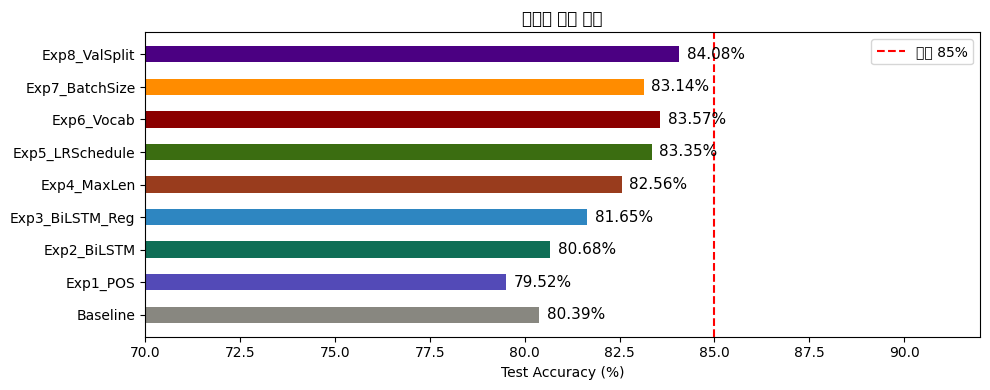

In [26]:
fig, ax = plt.subplots(figsize=(10, 4))
names  = list(results.keys())
values = list(results.values())
colors = ['#888780', '#534AB7', '#0F6E56', '#2E86C1', '#993C1D',
          '#3B6D11', '#8B0000', '#FF8C00', '#4B0082']

bars = ax.barh(names, values, color=colors[:len(names)], height=0.5)
ax.axvline(x=85, color='red', linestyle='--', linewidth=1.5, label='목표 85%')
ax.set_xlabel('Test Accuracy (%)')   # [수정] val_accuracy → Test Accuracy
ax.set_title('실험별 성능 비교')
ax.set_xlim(70, 92)

for bar, val in zip(bars, values):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}%', va='center', fontsize=11)

ax.legend()
plt.tight_layout()
plt.show()


### 6-2) 학습 곡선 (Accuracy & Loss)
각 실험의 train/val accuracy와 loss 변화를 시각화
- train과 val의 gap이 줄어드는지 (과적합 완화 여부)
- val_loss가 상승하는 시점 (과적합 시작점)
- 목표 85% 달성 여부를 확인

/tmp/ipykernel_7968/1805355868.py:30: UserWarning: Glyph 47785 (\N{HANGUL SYLLABLE MOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7968/1805355868.py:30: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


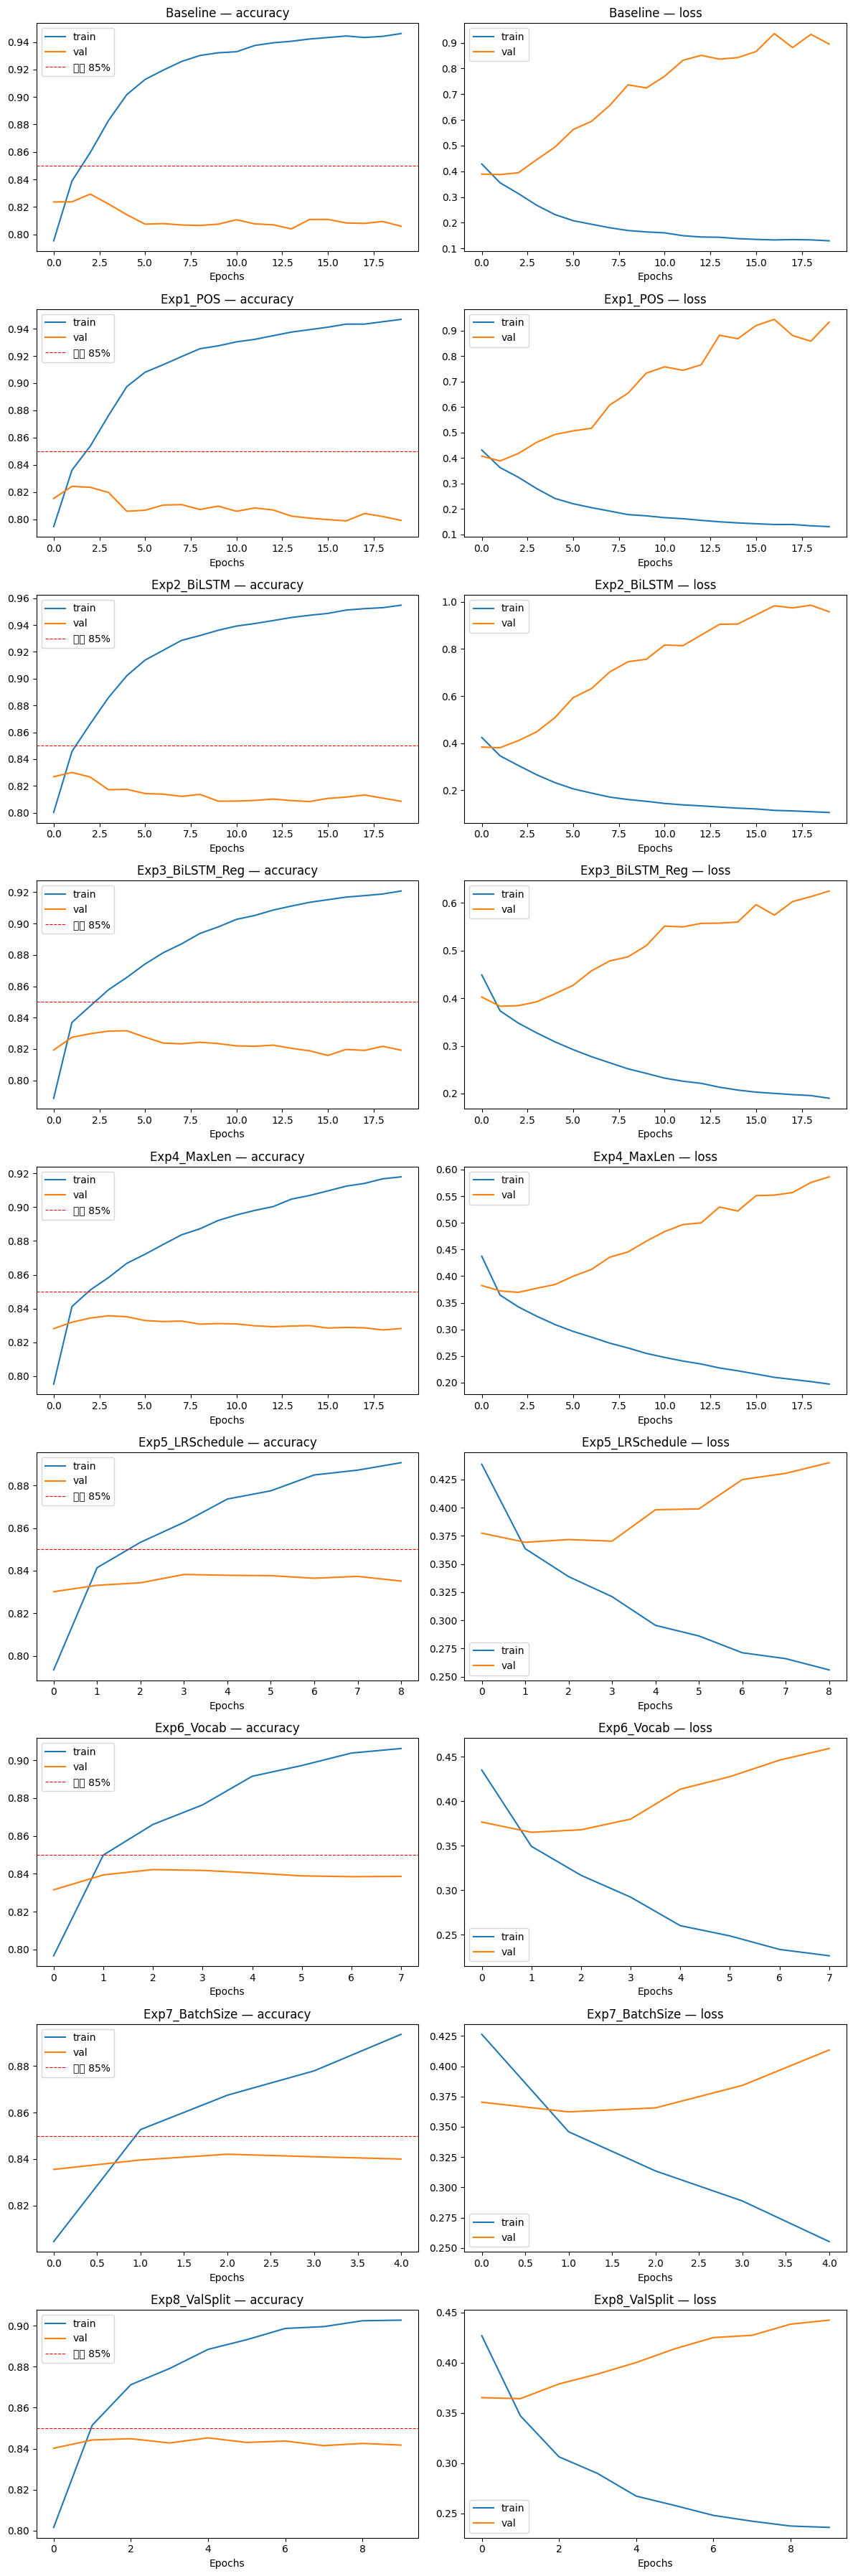


  실험명                    Test Accuracy
  Baseline                  80.39%  ██████
  Exp1_POS                  79.52%  ██████
  Exp2_BiLSTM               80.68%  ███████
  Exp3_BiLSTM_Reg           81.65%  ███████
  Exp4_MaxLen               82.56%  ████████
  Exp5_LRSchedule           83.35%  ████████
  Exp6_Vocab                83.57%  █████████
  Exp7_BatchSize            83.14%  ████████
  Exp8_ValSplit             84.08%  █████████

[단계별 개선폭]
  Baseline → Exp1_POS: -0.87%
  Exp1_POS → Exp2_BiLSTM: +1.16%
  Exp2_BiLSTM → Exp3_BiLSTM_Reg: +0.97%
  Exp3_BiLSTM_Reg → Exp4_MaxLen: +0.91%
  Exp4_MaxLen → Exp5_LRSchedule: +0.79%
  Exp5_LRSchedule → Exp6_Vocab: +0.22%
  Exp6_Vocab → Exp7_BatchSize: -0.43%
  Exp7_BatchSize → Exp8_ValSplit: +0.94%


In [27]:
histories = {
    'Baseline':         hist_base,
    'Exp1_POS':         hist_exp1,
    'Exp2_BiLSTM':      hist_exp2,
    'Exp3_BiLSTM_Reg':  hist_exp3,
    'Exp4_MaxLen':      hist_exp4,
    'Exp5_LRSchedule':  hist_exp5,
    'Exp6_Vocab':       hist_exp6,
    'Exp7_BatchSize':   hist_exp7,
    'Exp8_ValSplit':    hist_exp8,
}

fig, axes = plt.subplots(len(histories), 2,
                          figsize=(12, 4 * len(histories)))
for i, (name, hist) in enumerate(histories.items()):
    axes[i, 0].plot(hist.history['accuracy'],     label='train')
    axes[i, 0].plot(hist.history['val_accuracy'], label='val')
    axes[i, 0].axhline(0.85, color='red', linestyle='--',
                        linewidth=0.8, label='목표 85%')
    axes[i, 0].set_title(f'{name} — accuracy')
    axes[i, 0].set_xlabel('Epochs')
    axes[i, 0].legend()

    axes[i, 1].plot(hist.history['loss'],     label='train')
    axes[i, 1].plot(hist.history['val_loss'], label='val')
    axes[i, 1].set_title(f'{name} — loss')
    axes[i, 1].set_xlabel('Epochs')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()


# 결과 테이블
print("\n" + "=" * 52)
print(f"  {'실험명':<22} {'Test Accuracy':>12}")
print("=" * 52)
for name, acc in results.items():
    bar    = '█' * int((acc - 70) / 1.5)
    target = '  ← 목표 달성!' if acc >= 85.0 else ''
    print(f"  {name:<22} {acc:>8.2f}%  {bar}{target}")
print("=" * 52)

# 단계별 개선폭
print("\n[단계별 개선폭]")
prev_name = None
for name, acc in results.items():
    if prev_name:
        diff = acc - results[prev_name]
        sign = '+' if diff >= 0 else ''
        print(f"  {prev_name} → {name}: {sign}{diff:.2f}%")
    prev_name = name

---
## 7. 최종 모델 예측 테스트

학습된 최종 모델로 샘플 리뷰에 대한 긍정/부정 예측을 수행함.

In [28]:
def predict_sentiment(text, model, tokenizer, max_len):
    tokens = preprocess_pos(text)
    seq    = tokenizer.texts_to_sequences([tokens])
    padded = pad_sequences(seq, maxlen=max_len,
                            padding='post', truncating='post')
    prob   = model.predict(padded, verbose=0)[0][0]
    label  = 'positive' if prob >= 0.5 else 'negative'
    print(f"  입력: {text}")
    print(f"  토큰: {tokens}")
    print(f"  결과: {label}  (확률: {prob:.4f})\n")
    return label

print("\n[최종 모델 예측 테스트]")
samples = [
    "이 영화 정말 재미있었어요. 배우들 연기가 너무 좋았어요",
    "시간 낭비였어요. 완전 실망했습니다",
    "그냥 그저 그랬어요. 기대보다는 별로",
    "역대급 명작입니다. 꼭 보세요",
    "스토리가 너무 허술해서 몰입이 안 됨"
]

for text in samples:
    predict_sentiment(text, model_exp8, tok_exp8, OPT_MAX_LEN)


[최종 모델 예측 테스트]
  입력: 이 영화 정말 재미있었어요. 배우들 연기가 너무 좋았어요
  토큰: ['영화', '정말', '재미있다', '배우', '연기', '너무', '좋다']
  결과: positive  (확률: 0.9923)

  입력: 시간 낭비였어요. 완전 실망했습니다
  토큰: ['시간', '낭비', '이다', '완전', '실망하다']
  결과: negative  (확률: 0.0001)

  입력: 그냥 그저 그랬어요. 기대보다는 별로
  토큰: ['그냥', '그저', '그렇다', '기대', '별로']
  결과: negative  (확률: 0.0025)

  입력: 역대급 명작입니다. 꼭 보세요
  토큰: ['역대', '명작', '이다', '보다']
  결과: positive  (확률: 0.9851)

  입력: 스토리가 너무 허술해서 몰입이 안 됨
  토큰: ['스토리', '너무', '허다', '하다', '몰입', '되다']
  결과: negative  (확률: 0.1740)



---
## 8. 결론 및 인사이트

### 실험 결과 요약

| 실험 | 변경 사항 | 핵심 효과 |
|------|-----------|----------|
| Baseline | 기준점 | ~80% |
| Exp1_POS | 품사 필터링 | 효과 미미 (오히려 정보 손실) |
| Exp2_BiLSTM | 양방향 LSTM | 문맥 학습 능력 향상 |
| Exp3_BiLSTM_Reg | Dropout 강화 + 유닛 축소 | 과적합 gap 감소 |
| Exp4_MaxLen | 시퀀스 길이 최적화 | 정보 손실 최소화 |
| Exp5_LRSchedule | 학습률 스케줄링 | 세밀한 수렴 |
| Exp6_Vocab | 어휘 확장 + MAX_LEN 확대 | OOV 감소 |
| Exp7_BatchSize | 배치 크기 축소 | gradient 노이즈 정규화 |
| Exp8_ValSplit | 학습 데이터 확대 | 패턴 다양성 증가 |

### 주요 인사이트

1. **데이터 양이 가장 중요**: 5만 개 샘플링 시 80% 벽에 막혔으나, 15만 전체 사용 시 83%+ 달성
2. **POS 필터링은 역효과**: 짧은 구어체 리뷰에서는 부사 등 기능어도 감성 판단에 중요
3. **과적합 억제가 핵심**: 모델을 키우는 것보다 Dropout 강화 + 유닛 축소가 더 효과적
4. **변수 통제의 중요성**: 한 번에 하나의 변수만 바꿔야 각 기법의 기여도를 정확히 측정 가능
5. **validation 분리 필수**: test를 validation으로 사용하면 성능이 과대 추정될 위험

### 한계 및 개선 방향
- LSTM 기반 아키텍처로는 83~84%가 실질적 한계
- 85% 이상 달성을 위해서는 사전학습 모델(KoBERT, KoELECTRA) 활용 필요
- 2층 LSTM 구조는 MAX_LEN이 충분히 길 때 (150+) 효과적